In [4]:
import numpy as np
import scipy.io as sio
import vtk
from scipy.interpolate import interp1d
from vtk.util.numpy_support import numpy_to_vtk

import os
import cv2
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..", "Code")))
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import pandas as pd
from scripts.visualization.utils.renderizer import EGMRenderer_EGM


In [5]:
algorithm_ID="OMAMI_repeated"

In [6]:
csv_rmse=f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID}/rmse_df_test.csv"
df_rmse = pd.read_csv(csv_rmse)
csv_corr=f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID}/corr_df_test.csv"
df_corr = pd.read_csv(csv_corr)

# Rename columns to have a common column for merging
df_rmse.rename(columns={'names': 'name', }, inplace=True)

# Merge dataframes on the common column 'name'
df_merged = pd.merge(df_corr, df_rmse, on='name')
df_DL = df_merged.sort_values(by='mean correlation', ascending=False)

df_DL.rename(columns={'name': 'name', 'mean correlation': 'MeanCorr DL', 'mean RMSE': 'MeanRMSE DL'}, inplace=True)
df_DL=np.round(df_DL, 3)
df_DL.head(20)




,name,MeanCorr DL,MeanRMSE DL
11,Simulation_01_200212_001_ 5,0.593,0.437
2,Simulation_01_200316_001_ 3,0.589,0.419
5,Simulation_01_200316_001_ 8,0.247,0.521
6,Simulation_01_200428_001_004,0.224,0.536
3,Simulation_01_200316_001_ 4,0.197,0.542
10,Simulation_01_200428_001_008,0.184,0.533
8,Simulation_01_200428_001_010,0.102,0.551
7,Simulation_01_200212_001_ 10,0.050,0.566
9,LA_PLAW_140711_arm,0.028,0.528
4,Simulation_01_210208_001_002,0.025,0.486


In [7]:
print('DL --> Mean corr: ', np.round(df_DL['MeanCorr DL'].mean(), 3), '+-', np.round(df_DL['MeanCorr DL'].std(), 3) )
print('DL --> Mean RMSE: ', np.round(df_DL['MeanRMSE DL'].mean(), 3), '+-', np.round(df_DL['MeanRMSE DL'].std(), 3) )

DL --> Mean corr:  0.188 +- 0.208
DL --> Mean RMSE:  0.51 +- 0.047


In [8]:
sinusal = {
    "Simulation_01_200316_001_  7", "Simulation_01_210209_001_002",
    "Simulation_01_210205_001_002", "Simulation_01_200428_001_001",
    "Simulation_01_200316_001_ 5", "Simulation_01_200428_001_005",
    "Simulation_01_200212_001_  7", "Simulation_01_210119_001_001",
    "Simulation_01_210205_001_003", "Simulation_01_201223_001_002",
    "Simulation_01_200212_001_  1", "Simulation_01_200428_001_003",
    "Simulation_01_200316_001_  3", "Simulation_01_200316_001_  4",
    "Sinusal_150629", "RA_RAA_141216", "Simulation_01_200428_001_002",
    "Simulation_01_210210_001_001", "Simulation_01_210208_001_002",
    "Simulation_01_200212_001_  9", "Simulation_01_200316_001_  1",
    "Simulation_01_200212_001_  6", "Simulation_01_200212_001_  5",
    "Simulation_01_210209_001_003", "Simulation_01_200316_001_  9",
    "Simulation_01_210209_001_001", "Simulation_01_200428_001_006",
    "Simulation_01_200316_001_  5",
}

rotor_simple = {
    "Simulation_01_200212_001_  2", "Simulation_01_191001_001_002",
    "Simulation_01_190717_001_001", "Simulation_01_191001_001_007",
    "Simulation_01_190717_001_004", "Simulation_01_190619_001_003",
    "Simulation_01_190619_001_004", "Simulation_01_190717_001_003",
    "Simulation_01_190502_001_006", "Simulation_01_190502_001_004",
    "Simulation_01_190717_001_002", "Simulation_01_190619_001_001",
    "Simulation_01_200316_001_  8", "Simulation_01_200428_001_004",
    "Simulation_01_200212_001_  8", "Simulation_01_200212_001_10",
    "Simulation_01_191001_001_001", "Simulation_01_200428_001_007",
    "Simulation_01_200428_001_009", "Simulation_01_200428_001_010",
    "Simulation_01_200316_001_  2", "Simulation_01_200316_001_  6",
    "Simulation_01_200316_001_10", "Simulation_01_190502_001_003",
    "Simulation_01_190619_001_002", "Simulation_01_191001_001_005",
    "Simulation_01_200212_001_  4", "Simulation_01_200212_001_ 10",
    "Simulation_01_200428_001_008", "Simulation_01_190502_001_005"

}

rotor_complejo = {
    "LA_RSPV_CAF_150115", "LA_RSPV_150113'", "LA_PLAW_140612",
    "LA_LSPV_150203", "LA_LSPV_150113", "RA_RAFW_140807",
    "RA_RAA_141230", "TwoRotors_181219", "LA_PLAW_140711_arm",
    "RA_RAFW_SAF_140730", "LA_RIPV_150121", "LA_LIPV_150119"
}

# Función para clasificar cada fila
def classify_row(name):
    if name in sinusal:
        return 'Frente de Onda Sinusal'
    elif name in rotor_simple:
        return 'Rotor Simple'
    elif name in rotor_complejo:
        return 'Rotor Complejo'
    else:
        return 'Desconocido'




In [9]:
# Crear la nueva columna de clasificación
df_DL['classification'] = df_DL['name'].apply(classify_row)

print(df_DL)

                            name  MeanCorr DL  MeanRMSE DL  \
11  Simulation_01_200212_001_  5        0.593        0.437   
2   Simulation_01_200316_001_  3        0.589        0.419   
5   Simulation_01_200316_001_  8        0.247        0.521   
6   Simulation_01_200428_001_004        0.224        0.536   
3   Simulation_01_200316_001_  4        0.197        0.542   
10  Simulation_01_200428_001_008        0.184        0.533   
8   Simulation_01_200428_001_010        0.102        0.551   
7   Simulation_01_200212_001_ 10        0.050        0.566   
9             LA_PLAW_140711_arm        0.028        0.528   
4   Simulation_01_210208_001_002        0.025        0.486   
1   Simulation_01_210119_001_001        0.013        0.470   
0             LA_RSPV_CAF_150115        0.000        0.535   

            classification  
11  Frente de Onda Sinusal  
2   Frente de Onda Sinusal  
5             Rotor Simple  
6             Rotor Simple  
3   Frente de Onda Sinusal  
10            Rotor

In [10]:

csv_tik=f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID}/metrics_tik.csv"
path='/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/OMAMI_repeated/metrics_tik.csv'
df_tik = pd.read_csv(path)
df_tik = df_tik.sort_values(by='mean correlation', ascending=False)

df_tik.rename(columns={'name': 'name', 'mean correlation': 'MeanCorr ZOT', 'mean RMSE': 'MeanRMSE ZOT'}, inplace=True)
df_tik=np.round(df_tik, 3)
 #Crear la nueva columna de clasificación
df_tik['classification'] = df_DL['name'].apply(classify_row)
df_tik.head(20)

,name,MeanCorr ZOT,MeanRMSE ZOT,classification
10,Simulation_01_210119_001_001,0.603,0.316,Rotor Simple
11,Simulation_01_210208_001_002,0.597,0.359,Frente de Onda Sinusal
9,Simulation_01_200428_001_010,0.492,0.407,Rotor Complejo
7,Simulation_01_200428_001_004,0.486,0.433,Rotor Simple
5,Simulation_01_200316_001_ 4,0.476,0.436,Rotor Simple
8,Simulation_01_200428_001_008,0.474,0.424,Rotor Simple
6,Simulation_01_200316_001_ 8,0.471,0.440,Rotor Simple
3,Simulation_01_200212_001_ 10,0.459,0.446,Frente de Onda Sinusal
0,LA_PLAW_140711_arm,0.446,0.424,Rotor Complejo
4,Simulation_01_200316_001_ 3,0.435,0.430,Frente de Onda Sinusal


In [11]:
print('ZOT --> Mean corr: ', np.round(df_tik['MeanCorr ZOT'].mean(), 3), '+-', np.round(df_tik['MeanCorr ZOT'].std(), 3) )
print('ZOT --> Mean RMSE: ', np.round(df_tik['MeanRMSE ZOT'].mean(), 3), '+-', np.round(df_tik['MeanRMSE ZOT'].std(), 3) )
print('DL --> Mean corr: ', np.round(df_DL['MeanCorr DL'].mean(), 3), '+-', np.round(df_DL['MeanCorr DL'].std(), 3) )
print('DL --> Mean RMSE: ', np.round(df_DL['MeanRMSE DL'].mean(), 3), '+-', np.round(df_DL['MeanRMSE DL'].std(), 3) )


ZOT --> Mean corr:  0.475 +- 0.072
ZOT --> Mean RMSE:  0.416 +- 0.039
DL --> Mean corr:  0.188 +- 0.208
DL --> Mean RMSE:  0.51 +- 0.047


In [12]:
df_merged = pd.merge(df_DL,df_tik, on='name')
df_merged.head(20)


,name,MeanCorr DL,MeanRMSE DL,classification_x,MeanCorr ZOT,MeanRMSE ZOT,classification_y
0,Simulation_01_200212_001_ 5,0.593,0.437,Frente de Onda Sinusal,0.433,0.432,Frente de Onda Sinusal
1,Simulation_01_200316_001_ 3,0.589,0.419,Frente de Onda Sinusal,0.435,0.430,Frente de Onda Sinusal
2,Simulation_01_200316_001_ 8,0.247,0.521,Rotor Simple,0.471,0.440,Rotor Simple
3,Simulation_01_200428_001_004,0.224,0.536,Rotor Simple,0.486,0.433,Rotor Simple
4,Simulation_01_200316_001_ 4,0.197,0.542,Frente de Onda Sinusal,0.476,0.436,Rotor Simple
5,Simulation_01_200428_001_008,0.184,0.533,Rotor Simple,0.474,0.424,Rotor Simple
6,Simulation_01_200428_001_010,0.102,0.551,Rotor Simple,0.492,0.407,Rotor Complejo
7,Simulation_01_200212_001_ 10,0.050,0.566,Rotor Simple,0.459,0.446,Frente de Onda Sinusal
8,LA_PLAW_140711_arm,0.028,0.528,Rotor Complejo,0.446,0.424,Rotor Complejo
9,Simulation_01_210208_001_002,0.025,0.486,Frente de Onda Sinusal,0.597,0.359,Frente de Onda Sinusal


/tmp/ipykernel_127344/347673866.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([numerical_columns[col] for col in rmse_columns], labels=rmse_columns)


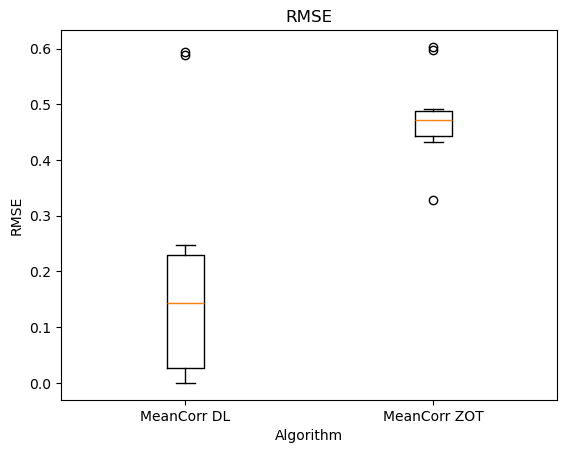

In [13]:
# Crear el boxplot solo con las columnas numéricas
numerical_columns = df_merged.select_dtypes(include="number")  # Seleccionar solo columnas numéricas
# Filtrar las columnas que contienen "RMSE" en su nombre
rmse_columns = [col for col in numerical_columns.columns if "RMSE" in col]
rmse_columns = [col for col in numerical_columns.columns if "Corr" in col]


plt.figure()
plt.boxplot([numerical_columns[col] for col in rmse_columns], labels=rmse_columns)
plt.title("RMSE")
plt.ylabel("RMSE")
plt.xlabel("Algorithm")
plt.show()


/tmp/ipykernel_127344/4251478.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([numerical_columns[col] for col in rmse_columns], labels=rmse_columns)


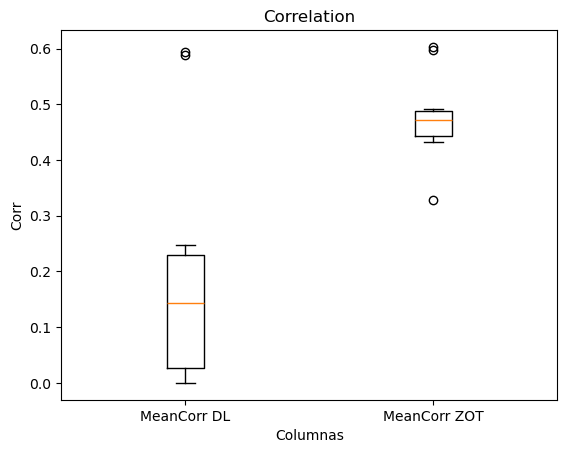

In [14]:

# Crear el boxplot solo para las columnas que contienen "RMSE"
plt.boxplot([numerical_columns[col] for col in rmse_columns], labels=rmse_columns)
plt.title("Correlation")
plt.ylabel("Corr")
plt.xlabel("Columnas")
plt.show()

In [15]:
print('ZOT --> Mean corr: ', np.round(df_tik['MeanCorr ZOT'].mean(), 3), '+-', np.round(df_tik['MeanCorr ZOT'].std(), 3) )
print('ZOT --> Mean RMSE: ', np.round(df_tik['MeanRMSE ZOT'].mean(), 3), '+-', np.round(df_tik['MeanRMSE ZOT'].std(), 3) )
print('DL --> Mean corr: ', np.round(df_DL['MeanCorr DL'].mean(), 3), '+-', np.round(df_DL['MeanCorr DL'].std(), 3) )
print('DL --> Mean RMSE: ', np.round(df_DL['MeanRMSE DL'].mean(), 3), '+-', np.round(df_DL['MeanRMSE DL'].std(), 3) )


ZOT --> Mean corr:  0.475 +- 0.072
ZOT --> Mean RMSE:  0.416 +- 0.039
DL --> Mean corr:  0.188 +- 0.208
DL --> Mean RMSE:  0.51 +- 0.047
